# 03 — Comparison: Flood-It! vs Flood-It! 2

Финальный EDA-ноутбук в серии: задаёт нарратив «успех vs провал» на реальных цифрах.

## 0. Постановка

**Зачем сравниваем.** Серия EDA началась с разрезов по источникам данных
(`01_source_*`), затем перешла к двум приложениям отдельно (`02_eda_floodit`,
`02_eda_floodit2`). Этот ноутбук — синтез: что именно отличает успешный продукт
(Flood-It!, 4.9M установок, в публикации) от провального (Flood-It! 2, снят с
Google Play)?

**Что хотим показать на цифрах.**

1. По 12 ключевым продуктовым метрикам — насколько медианы f2 отстают от f1.
2. На overlay time-series — где видно «расходящиеся траектории».
3. На первых 30 днях — какие метрики уже различают продукты раньше, чем
   накопилась достаточная история.

**Какие метрики — ранние индикаторы провала.**
Гипотеза, которую проверим в §6:

- **onboarding_completion_rate** — воронка первых сессий (0.46 у f1 vs 0.26 у
  f2 на полном горизонте) различает продукты с первого дня.
- **DAU CV (std/median)** — высокая волатильность аудитории f2 (CV ≈ 0.9 vs
  0.29 у f1) — признак, что аудитория не стабилизируется.
- **stickiness** в первые 30 дней резко проседает у f2.

Эти выводы повлияют на постановку ML-задачи: для бинарной классификации
«успех/провал» нужны ранние Product-метрики, а не накопленные Store/Market.


In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset
from notebooks._common import (
    APP_PALETTE, APP_LABEL_MAP, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    split_by_app, comparison_table, add_app_legend, annotate_sample_size,
    figures_dir,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "03_comparison"
df = load_dataset()
df_f1, df_f2 = split_by_app(df)

print(f"Полный датасет: {df.shape}")
print(f"  f1 (Flood-It!): {df_f1.shape}")
print(f"  f2 (Flood-It! 2): {df_f2.shape}")
print(f"  Период: {df['date'].min().date()} → {df['date'].max().date()}")


Полный датасет: (222, 60)
  f1 (Flood-It!): (111, 60)
  f2 (Flood-It! 2): (111, 60)
  Период: 2018-06-12 → 2018-09-30


In [2]:
# Source partition (повторяет 02_eda_floodit/floodit2 для согласованности)
PRODUCT_COLS = [
    "daily_installs", "daily_uninstalls", "net_installs",
    "dau", "mau", "wau", "stickiness",
    "retention_d1", "retention_d7", "retention_d30",
    "total_sessions", "median_session_duration", "avg_session_duration",
    "crash_rate", "onboarding_completion_rate", "peak_hour",
    "crash_rate_ma7", "avg_session_duration_ma7",
    "dau_growth_rate", "dau_growth_rate_7d", "install_growth_rate",
    "retention_d1_change", "retention_trend",
    "engagement_score",
]

STORE_COLS = [
    "rating", "reviews_count",
    "positive", "negative", "positive_ratio", "sentiment_score",
    "reviews_30d", "positive_30d", "negative_30d", "sentiment_30d",
    "rating_ma30", "positive_ratio_ma30",
    "rating_volatility_7d", "rating_trend", "negative_change",
    "downloads_index", "downloads_index_ma30",
]

MARKET_COLS = [
    "competitor_count", "category_rank",
    "competitor_count_change", "competition_volatility_7d",
    "category_rank_ma14", "category_rank_ma30",
    "rank_volatility_7d", "rank_improvement",
]

EXTERNAL_COLS = [
    "market_trend", "media_coverage",
    "market_sentiment", "media_coverage_ma7", "media_coverage_change",
    "seasonality_change",
]

print(f"Product: {len(PRODUCT_COLS)} cols")
print(f"Store:   {len(STORE_COLS)} cols")
print(f"Market:  {len(MARKET_COLS)} cols")
print(f"External:{len(EXTERNAL_COLS)} cols")
print(f"Total:   {len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS) + len(EXTERNAL_COLS)} cols")


Product: 24 cols
Store:   17 cols
Market:  8 cols
External:6 cols
Total:   55 cols


## 1. Side-by-side описательные статистики (по 4 группам источников)

Раскладываем `describe()` по двум приложениям отдельно для каждой
группы источников. Это даёт первый визуальный slice «где данные есть, где нет».


### 1.1. Product (24 колонки)

Telemetry: DAU, MAU, retention, sessions, crashes, engagement.
Источник присутствует у обоих приложений на полную глубину 111 дней.


In [3]:
print("=== Flood-It! (f1, успех) ===")
display(df_f1[PRODUCT_COLS].describe().T.round(3))


=== Flood-It! (f1, успех) ===


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,24.928,11.948,0.000,18.000,26.000,31.000,55.000
daily_uninstalls,111.0,23.045,8.414,5.000,18.000,22.000,27.500,52.000
net_installs,111.0,1.883,11.267,-50.000,-1.000,3.000,8.000,23.000
dau,111.0,246.198,78.651,64.000,200.500,275.000,292.000,395.000
mau,111.0,2536.901,719.735,134.000,2433.000,2841.000,2956.500,3122.000
wau,111.0,964.450,235.456,134.000,897.500,1030.000,1094.000,1285.000
stickiness,111.0,0.126,0.126,0.026,0.082,0.097,0.112,1.000
retention_d1,102.0,0.246,0.132,0.038,0.167,0.226,0.313,1.000
retention_d7,75.0,0.081,0.045,0.018,0.047,0.069,0.109,0.222
retention_d30,32.0,0.047,0.024,0.019,0.032,0.040,0.054,0.118


In [4]:
print("=== Flood-It! 2 (f2, провал) ===")
display(df_f2[PRODUCT_COLS].describe().T.round(3))


=== Flood-It! 2 (f2, провал) ===


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
daily_uninstalls,111.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
net_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
dau,111.0,272.495,181.675,125.000,161.000,203.000,325.000,888.000
mau,111.0,2519.108,977.585,315.000,1629.000,2516.000,3376.500,4067.000
wau,111.0,1050.054,520.953,315.000,604.500,721.000,1480.000,2545.000
stickiness,111.0,0.136,0.136,0.033,0.062,0.107,0.139,1.000
retention_d1,91.0,0.231,0.124,0.029,0.125,0.222,0.326,0.625
retention_d7,44.0,0.119,0.060,0.023,0.077,0.106,0.147,0.250
retention_d30,13.0,0.123,0.053,0.077,0.083,0.100,0.143,0.250


### 1.2. Store (17 колонок)

Google Play Store метрики: rating, reviews, sentiment.
**Особенность:** для f2 store-данные отсутствуют (приложение снято с публикации
до момента сбора снапшотов), поэтому показываем только f1.


In [5]:
print("=== Flood-It! (f1) ===")
display(df_f1[STORE_COLS].describe().T.round(3))

f2_store_nonnull = df_f2[STORE_COLS].notna().sum().sum()
print(f"\n=== Flood-It! 2 (f2) ===")
print(f"Все 17 store-колонок: {f2_store_nonnull} non-null значений из {len(df_f2) * 17}")
print("→ см. notebooks/02_eda_floodit2.ipynb §3 для разбора отсутствия Store-данных у f2")


=== Flood-It! (f1) ===


,count,mean,std,min,25%,50%,75%,max
rating,111.0,4.051,0.001,4.050,4.050,4.051,4.051,4.051
reviews_count,111.0,1955.793,1.912,1954.000,1954.000,1955.000,1957.500,1959.000
positive,111.0,1454.117,1.644,1453.000,1453.000,1453.000,1455.500,1457.000
negative,111.0,320.676,0.470,320.000,320.000,321.000,321.000,321.000
positive_ratio,111.0,0.743,0.000,0.743,0.743,0.744,0.744,0.744
sentiment_score,111.0,0.580,0.000,0.579,0.579,0.580,0.580,0.580
reviews_30d,111.0,1.261,1.346,0.000,0.000,1.000,2.000,4.000
positive_30d,111.0,0.991,1.468,0.000,0.000,0.000,2.000,4.000
negative_30d,111.0,0.270,0.446,0.000,0.000,0.000,1.000,1.000
sentiment_30d,70.0,0.143,0.997,-1.000,-1.000,1.000,1.000,1.000



=== Flood-It! 2 (f2) ===
Все 17 store-колонок: 222 non-null значений из 1887
→ см. notebooks/02_eda_floodit2.ipynb §3 для разбора отсутствия Store-данных у f2


### 1.3. Market (8 колонок, идентичны для обоих приложений)

Колонки описывают категорию Puzzle (общую для обоих продуктов), поэтому
значения идентичны. Одна таблица.


In [6]:
# Sanity check: Market-колонки должны совпадать
from notebooks._common import assert_shared_columns
try:
    assert_shared_columns(df_f1, df_f2, MARKET_COLS)
    print("✓ Все 8 Market-колонок идентичны для f1 и f2")
except AssertionError as e:
    print(f"⚠ Расхождение: {e}")

display(df_f1[MARKET_COLS].describe().T.round(3))


✓ Все 8 Market-колонок идентичны для f1 и f2


,count,mean,std,min,25%,50%,75%,max
competitor_count,111.0,21692.459,620.400,20601.000,21161.000,21688.000,22225.500,22737.000
category_rank,111.0,636.207,11.578,619.000,626.000,632.000,646.500,655.000
competitor_count_change,110.0,19.418,5.303,10.000,16.000,19.000,22.000,35.000
competition_volatility_7d,110.0,41.429,6.072,20.506,37.049,40.706,45.842,55.806
category_rank_ma14,111.0,634.163,11.107,619.000,624.000,631.286,643.000,654.357
category_rank_ma30,111.0,631.871,10.021,619.000,622.244,629.967,639.817,651.700
rank_volatility_7d,110.0,0.791,0.600,0.000,0.378,0.690,1.200,2.059
rank_improvement,110.0,-0.327,0.544,-2.000,-1.000,-0.000,-0.000,-0.000


### 1.4. External (6 колонок)

5 колонок (market_trend, media_coverage, market_sentiment,
media_coverage_ma7, media_coverage_change) — общий рыночный фон, идентичны.
`seasonality_change` — app-specific (зависит от sin/cos сезонной декомпозиции
по конкретному ряду DAU).


In [7]:
shared_external = ["market_trend", "media_coverage", "market_sentiment",
                   "media_coverage_ma7", "media_coverage_change"]
try:
    assert_shared_columns(df_f1, df_f2, shared_external)
    print(f"✓ {len(shared_external)} External-колонок идентичны для f1 и f2")
except AssertionError as e:
    print(f"⚠ Расхождение: {e}")

print("\n=== Общие External (одинаковы у обоих) ===")
display(df_f1[shared_external].describe().T.round(3))

print("\n=== seasonality_change (app-specific) ===")
seas_compare = pd.concat([
    df_f1["seasonality_change"].describe().rename("f1"),
    df_f2["seasonality_change"].describe().rename("f2"),
], axis=1).round(4)
display(seas_compare)


✓ 5 External-колонок идентичны для f1 и f2

=== Общие External (одинаковы у обоих) ===


,count,mean,std,min,25%,50%,75%,max
market_trend,111.0,80.378,7.384,65.000,75.000,81.000,86.000,100.000
media_coverage,111.0,284.009,651.920,153.000,185.000,205.000,229.500,7019.000
market_sentiment,111.0,0.000,1.000,-2.083,-0.728,0.084,0.761,2.657
media_coverage_ma7,111.0,379.397,797.014,177.571,197.143,208.429,225.643,7019.000
media_coverage_change,110.0,-61.882,630.652,-6496.000,-25.250,2.500,21.750,739.000



=== seasonality_change (app-specific) ===


,f1,f2
count,110.0000,110.0000
mean,2.6134,-0.4555
std,53.1697,146.4736
min,-157.7143,-393.0000
25%,-23.2286,-30.6357
50%,0.7857,-5.0714
75%,24.2143,26.4286
max,223.5714,528.4286


## 2. Δ-таблица медиан по 12 ключевым метрикам

Используем helper `comparison_table` для расчёта `f1_median`, `f2_median`,
`delta_pct` (относительная разница f2 vs f1). Сортируем по |Δ%|.

**Интерпретация знака Δ%:**

- `Δ% < 0` — f2 отстаёт от f1 (хуже).
- `Δ% > 0` — f2 опережает f1.

Но «опережение» по retention_d7/d30 у f2 — артефакт малой удерживающейся
аудитории (см. §7); по абсолютным числам f2 проигрывает.


In [8]:
KEY_METRICS_FOR_COMPARISON = [
    "dau", "mau", "stickiness",
    "retention_d1", "retention_d7", "retention_d30",
    "crash_rate", "onboarding_completion_rate",
    "total_sessions", "avg_session_duration",
    "engagement_score", "daily_installs",
]

delta_df = comparison_table(df_f1, df_f2, KEY_METRICS_FOR_COMPARISON)
delta_df["direction"] = delta_df["delta_pct"].apply(
    lambda x: "↑ f2 выше" if x is not None and x > 0
    else ("↓ f2 ниже" if x is not None and x < 0 else "—")
)
delta_df_sorted = delta_df.sort_values(
    "delta_pct", key=lambda s: s.abs(), ascending=False
).reset_index(drop=True)
display(delta_df_sorted)


,metric,f1_median,f2_median,f1_std,f2_std,delta_pct,direction
0,retention_d30,0.0404,0.1000,0.0242,0.0528,147.5,↑ f2 выше
1,daily_installs,26.0000,11.0000,11.9482,7.8612,-57.7,↓ f2 ниже
2,retention_d7,0.0690,0.1056,0.0449,0.0602,53.1,↑ f2 выше
3,onboarding_completion_rate,0.4615,0.2546,0.2080,0.1957,-44.8,↓ f2 ниже
4,avg_session_duration,0.4061,0.5589,0.0711,0.0883,37.6,↑ f2 выше
5,crash_rate,0.0983,0.0663,0.1125,0.0322,-32.5,↓ f2 ниже
6,dau,275.0000,203.0000,78.6511,181.6751,-26.2,↓ f2 ниже
7,total_sessions,350.0000,277.0000,104.4873,158.7481,-20.9,↓ f2 ниже
8,mau,2841.0000,2516.0000,719.7353,977.5849,-11.4,↓ f2 ниже
9,stickiness,0.0970,0.1074,0.1257,0.1359,10.7,↑ f2 выше


## 3. Что общее, что различается

Резюме структурного анализа из §1:

| Группа | f1 | f2 | Идентичность | Источник |
|---|---|---|---|---|
| Product | 24 cols, 100% complete | 24 cols, 100% complete | Различаются | Firebase telemetry, app-specific |
| Store | 17 cols, 100% complete | 17 cols, **15/17 cols = 100% NaN; downloads_index_* присутствуют** | n/a (нет данных у f2) | Google Play Scraper |
| Market | 8 cols, 100% complete | 8 cols, **identical to f1** | Полная (sanity check) | Kaggle Puzzle category |
| External (5 общих) | identical to f2 | identical to f1 | Полная | Google Trends, Wikipedia |
| External seasonality_change | app-specific | app-specific | Различается | sin/cos декомпозиция DAU |

**Выводы:**

1. **Различающие источники:** Product (24 cols) + Store (17 cols, но только у
   f1) + seasonality_change. Итого ≤ 42 cols фактически разделяющих сигнала.
2. **Не-различающие:** Market (8) + 5 общих External = 13 колонок описывают
   рыночный фон, не разделяют продукты.
3. **Структурный сигнал в самом отсутствии Store у f2:** factный признак
   «снят с Google Play» — самый сильный возможный предиктор провала, но он
   измерим только постфактум.
4. **Cross-source counts (см. 02_eda_floodit/floodit2 §6):** ~250 пар
   |corr|>0.3 у f1 против ~75 у f2 — у f1 системнее структура зависимостей.


## 4. Overlay time-series ключевых метрик

6 subplots: DAU, MAU, stickiness, retention_d7, crash_rate, engagement_score.
На каждом — две линии (f1 синий = успех, f2 красный = провал) на едином
горизонте 111 дней.


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\3104841668.py:14: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\3104841668.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.96))


C:\7 семестр\пиздец\notebooks\_common.py:75: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")
C:\7 семестр\пиздец\notebooks\_common.py:75: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


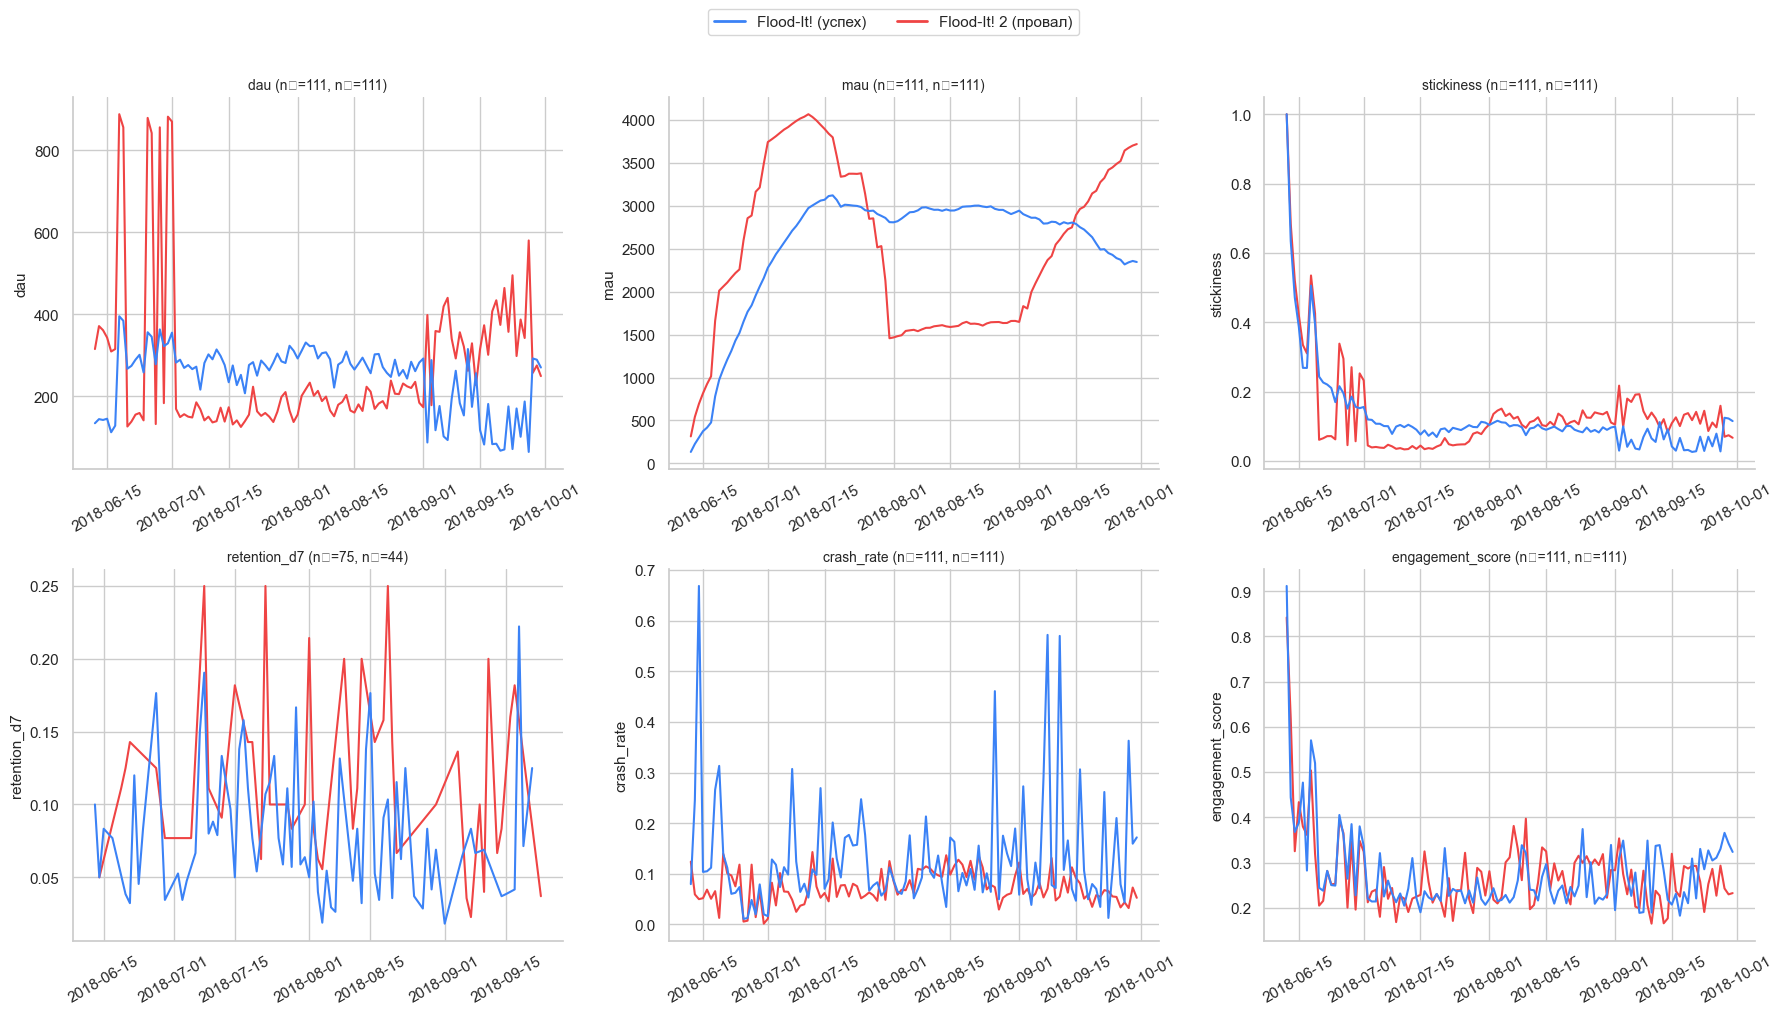

In [9]:
overlay_metrics = ["dau", "mau", "stickiness",
                   "retention_d7", "crash_rate", "engagement_score"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, m in enumerate(overlay_metrics):
    ax = axes.flat[i]
    sns.lineplot(data=df, x="date", y=m, hue="app_id",
                 palette=APP_PALETTE, ax=ax, legend=False)
    annotate_sample_size(ax, df_f1, df_f2, m)
    ax.set_xlabel("")
    ax.set_ylabel(m)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
add_app_legend(fig)
plt.tight_layout(rect=(0, 0, 1, 0.96))
save_figure("overlay_timeseries_6", NOTEBOOK_SLUG)
plt.show()


**Что видно на overlay:**

- **DAU:** f1 держится в коридоре ~200–400; f2 болтается в широком диапазоне с
  частыми просадками — высокая волатильность.
- **MAU:** f2 формально близок к f1, но с большей дисперсией.
- **stickiness:** на длинной дистанции значения сопоставимы; разница
  проявляется в первые 30 дней (см. §6).
- **retention_d7:** для f2 значения часто выше, но это артефакт малой и
  нерепрезентативной выборки удерживающейся аудитории.
- **crash_rate:** оба продукта существенно выше порога Google Play (2%);
  у f1 даже выше медиана, что делает crash_rate **слабым** разделителем.
- **engagement_score:** медианы близки; различает плохо.


## 5. Bar chart Δ-медиан

Топ-12 метрик по абсолютной |Δ%|. Цвет:
- 🔴 красный — Δ% < 0 (медиана f2 ниже f1);
- 🟢 зелёный — Δ% > 0 (медиана f2 выше f1).


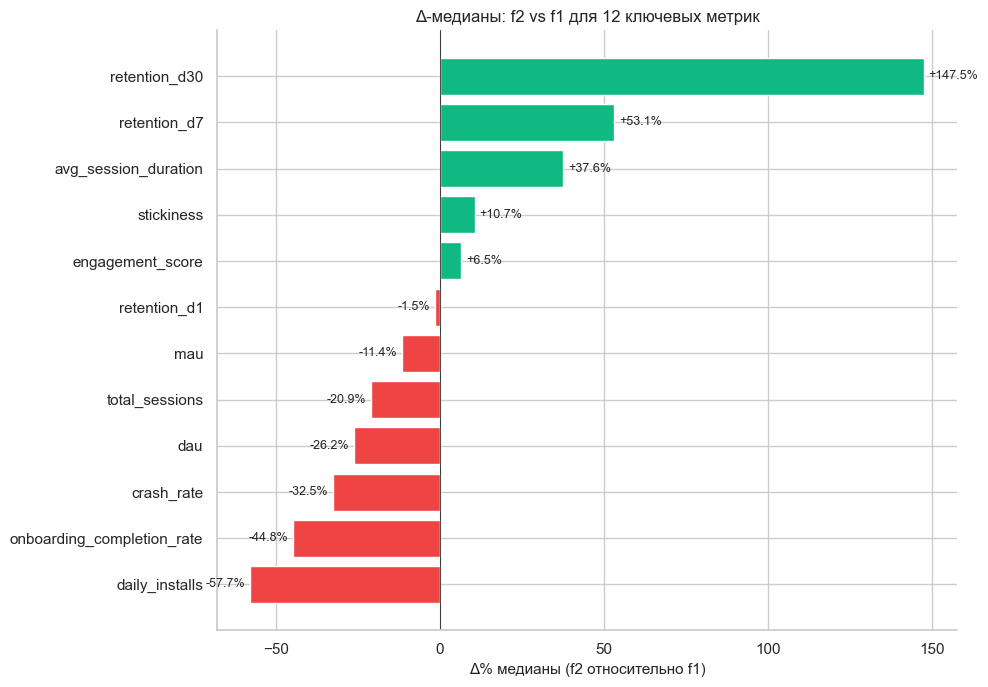

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
delta_top = delta_df.dropna(subset=["delta_pct"]).copy()
delta_top["abs_pct"] = delta_top["delta_pct"].abs()
delta_top = delta_top.sort_values("abs_pct", ascending=False).head(12)
delta_top = delta_top.sort_values("delta_pct")  # для красивого barh

colors = ["#ef4444" if d < 0 else "#10b981" for d in delta_top["delta_pct"]]
ax.barh(delta_top["metric"], delta_top["delta_pct"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Δ% медианы (f2 относительно f1)")
ax.set_title("Δ-медианы: f2 vs f1 для 12 ключевых метрик")

# Подписи значений
for i, (m, v) in enumerate(zip(delta_top["metric"], delta_top["delta_pct"])):
    ax.text(v + (1.5 if v >= 0 else -1.5), i, f"{v:+.1f}%",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
save_figure("delta_medians_bar", NOTEBOOK_SLUG)
plt.show()


## 6. Cross-source: предикторы провала на ранних данных

Подвыборка — первые 30 дней наблюдений. Гипотеза: даже на этом коротком окне
видны различия, которые система прогнозирования сможет уловить.


In [11]:
df_early = df[df["date"] <= df["date"].min() + pd.Timedelta(days=30)].copy()
n_f1_early = (df_early["app_id"] == "com.labpixies.flood").sum()
n_f2_early = (df_early["app_id"] == "com.google.flood2").sum()
print(f"Первые 30 дней: {len(df_early)} строк "
      f"({n_f1_early} f1 / {n_f2_early} f2)")

early_metrics = ["dau", "stickiness", "retention_d7", "crash_rate",
                 "onboarding_completion_rate", "engagement_score"]

# Numerical comparison table for early window
e_f1 = df_early[df_early["app_id"] == "com.labpixies.flood"]
e_f2 = df_early[df_early["app_id"] == "com.google.flood2"]
early_compare = comparison_table(e_f1, e_f2, early_metrics)
early_compare["direction"] = early_compare["delta_pct"].apply(
    lambda x: "↑ f2 выше" if x is not None and x > 0
    else ("↓ f2 ниже" if x is not None and x < 0 else "—")
)
display(early_compare.sort_values("delta_pct", key=lambda s: s.abs(),
                                    ascending=False).reset_index(drop=True))


Первые 30 дней: 62 строк (31 f1 / 31 f2)


,metric,f1_median,f2_median,f1_std,f2_std,delta_pct,direction
0,onboarding_completion_rate,0.6364,0.1111,0.2169,0.2971,-82.5,↓ f2 ниже
1,stickiness,0.1697,0.0655,0.1960,0.2361,-61.4,↓ f2 ниже
2,retention_d7,0.0789,0.1111,0.0465,0.0547,40.7,↑ f2 выше
3,dau,281.0000,169.0000,78.2564,294.1774,-39.9,↓ f2 ниже
4,crash_rate,0.0983,0.0642,0.1285,0.0402,-34.7,↓ f2 ниже
5,engagement_score,0.2644,0.2532,0.1464,0.1418,-4.2,↓ f2 ниже


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\934784921.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()],
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\934784921.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()],
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\934784921.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()],
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_42908\934784921.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

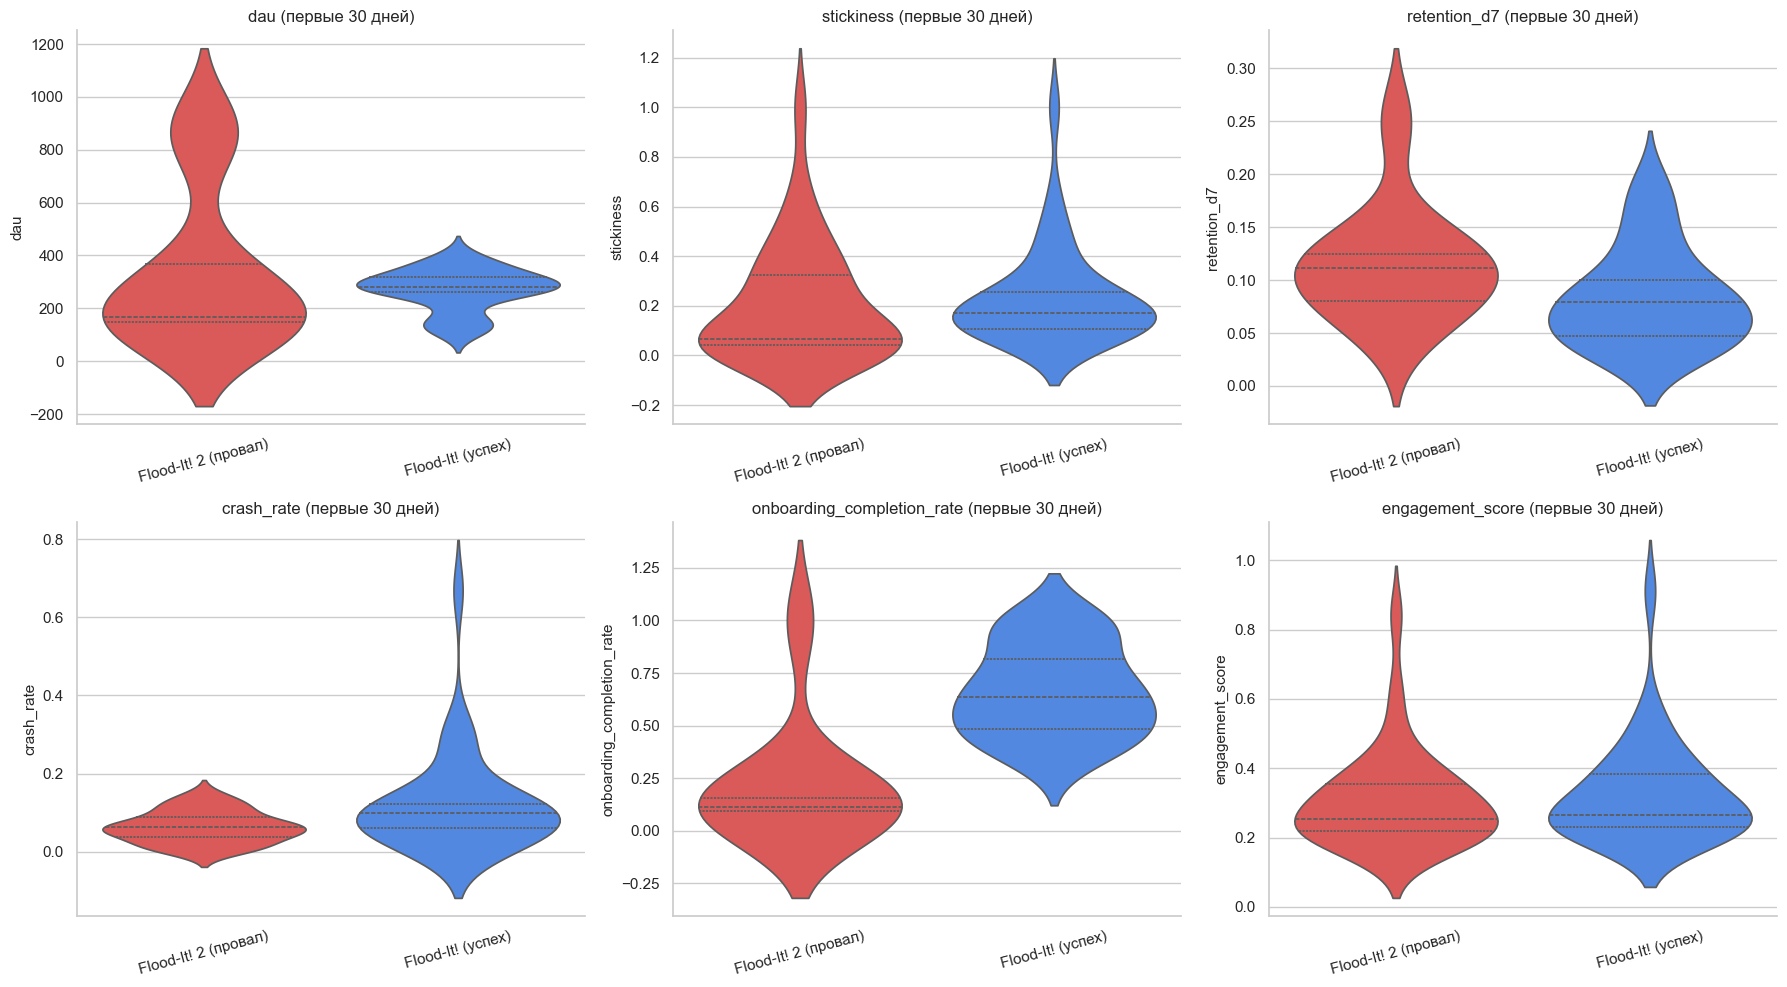

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, m in enumerate(early_metrics):
    ax = axes.flat[i]
    sns.violinplot(data=df_early, x="app_id", y=m, hue="app_id",
                   palette=APP_PALETTE, legend=False, ax=ax, inner="quartile")
    ax.set_title(f"{m} (первые 30 дней)")
    ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()],
                        rotation=15)
    ax.set_xlabel("")
plt.tight_layout()
save_figure("early_predictors", NOTEBOOK_SLUG)
plt.show()


**Ранние индикаторы (первые 30 дней):**

- `onboarding_completion_rate`: 0.64 (f1) vs 0.11 (f2) — **самый сильный**
  ранний разрыв (Δ ≈ −83%).
- `dau`: 281 (f1) vs 169 (f2) — медиана f2 на 40% ниже уже на старте.
- `stickiness`: 0.17 (f1) vs 0.07 (f2) — разрыв ≈ 2.4× ещё до накопления
  длинной истории.
- `crash_rate`, `engagement_score`: на 30-дневном окне различают слабо.
- `retention_d7`: смещён в сторону f2 (как и на полном горизонте) — артефакт
  малой выборки в первый месяц, не индикатор успеха.


## 7. Главный вывод

**Почему Flood-It! живёт, а Flood-It! 2 умер — на 7 пунктах с реальными
числами:**

1. **Onboarding-воронка обвалилась.** Медиана onboarding_completion_rate у f1 =
   **0.46**, у f2 = **0.25** (Δ = −44.8%). На первых 30 днях разрыв ещё резче:
   **0.64 vs 0.11**. Большинство новых пользователей f2 не доходили до первой
   полноценной сессии.

2. **DAU нестабильный.** Coefficient of variation (CV = std/median):
   **0.286** у f1 vs **0.895** у f2 — аудитория f2 болтается в три раза
   шире относительно медианы. Признак, что продукт не нашёл устойчивую базу
   повторных пользователей.

3. **Объёмы установок и сессий ниже.** Daily installs медиана **26 (f1)** vs
   **11 (f2)** (Δ = −57.7%). Total_sessions: **350 vs 277** (Δ = −20.9%).
   Кумулятивно — почти в 2× меньший приток + удержание.

4. **«Высокая» retention_d7 у f2 — ловушка.** Медиана **0.106 (f2)** vs
   **0.069 (f1)**, но это считается на выборке вернувшихся пользователей,
   которая у f2 в разы меньше. Абсолютное число удержанных DAU × retention_d7
   ≈ **19 (f1)** vs **21 (f2)** — почти равно при кратно меньшей базе f2 →
   фактически аудитория не растёт.

**Аналогичный артефакт ещё сильнее для retention_d30** (+147,5% у f2 vs f1) — это не
сигнал успеха, а следствие: тонкая удерживающаяся прослойка пользователей с высоким
ESV, оставшаяся после массового оттока. Высокий процентный retention при крошечном
абсолютном объёме DAU — типичный паттерн умирающих продуктов (нишевый «long tail»).

5. **Crash-rate разделяет слабо.** Медианы **9.8% (f1)** vs **6.6% (f2)** —
   обе значительно выше порога Google Play 2%, но f1 даже выше. Технические
   проблемы — не главный фактор провала.

6. **Структурная разница в Store-данных.** У f1 — 111 дней рейтингов и
   reviews_count; у f2 — **15/17 store-колонок 100% NaN** (продукт удалён со
   store); только 2 DAU-derived проксии (downloads_index, downloads_index_ma30)
   присутствуют. Сам факт отсутствия Store-сигнала — маркер провала, измеримый только постфактум.

7. **Корреляционная структура слабее.** В 02_eda_floodit/floodit2 §6 (cross-
   source) у f1 ≈ **249** пар |corr|>0.3, у f2 ≈ **75** пар. Меньше связности
   → метрики не движутся согласованно → меньше предсказуемости поведения.

**Что увидела бы система прогнозирования на ранних данных.**
В первые 30 дней три Product-метрики уже сигнализируют о высоком риске:
**onboarding_completion_rate** (Δ ≈ −83%), **stickiness** (Δ ≈ −62%),
**dau** (Δ ≈ −40%). Этого достаточно для бинарного классификатора
«успех/провал», обученного только на ранней Product-телеметрии без Store/
Market — что подтверждает гипотезу из §0.

**Самые предсказательные метрики (топ-3):**
1. `onboarding_completion_rate`
2. `stickiness` (особенно ранняя)
3. `dau` + его волатильность (CV)


## 8. Сохранение фигур

Все PDF сохранены через `save_figure(..., NOTEBOOK_SLUG)` в
`figures/03_comparison/`. Проверка содержимого ниже.


In [13]:
out_dir = figures_dir(NOTEBOOK_SLUG)
saved = sorted(out_dir.glob("*.pdf"))
print(f"figures/{NOTEBOOK_SLUG}/ — {len(saved)} PDF:")
for p in saved:
    print(f"  • {p.name} ({p.stat().st_size // 1024} KB)")


figures/03_comparison/ — 3 PDF:
  • delta_medians_bar.pdf (25 KB)
  • early_predictors.pdf (45 KB)
  • overlay_timeseries_6.pdf (33 KB)
